## Image and pixel color clustering algorithm

Have you ever wondered if you turn a picture of something and quantify how much of the picture is brown, white etc...? This code can be used to answer important questions like: "Is my cat 30% light brown, 50% dark brown and 20% white"?

Here we use an image of a cat (as an example) with background removed, convert image to RGB, convert pixel values into a numpy array which is then 'flattened' into a feature table (each row is a pixel with three column values of red, green blue).

We then cluster these features using k-means

Number of pixels of image 'images/bg-removed/image_1.png': 1991217


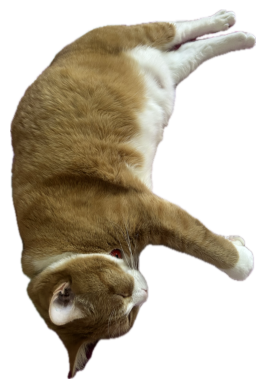

In [5]:
from PIL import Image
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

 # Load image helper function
def load_image(image_path):
    ''' Loads an image and converts it to RGBA format'''
    img = Image.open(image_path).convert("RGBA")
    if img is None:
        raise ValueError(f"Failed to load image from {image_path}")
    
    # Check if image has transparency, if not, make it transparent
    if img.mode != "RGBA":
        img = img.convert("RGBA")
    
    # Check if image actually has any transparent pixels
    alpha = np.array(img)[:, :, 3]
    if alpha.min() == 255:  # No transparency detected
        # Make background transparent (assuming white or similar background)
        data = np.array(img)
        # Convert white/near-white pixels to transparent
        mask = (data[:, :, 0] > 200) & (data[:, :, 1] > 200) & (data[:, :, 2] > 200)
        data[mask, 3] = 0
        img = Image.fromarray(data, "RGBA")
    
    # Print image dimensions and pixel count
    print(f"Number of pixels of image '{image_path}': {img.width * img.height}")

    # Display the image
    plt.imshow(img)
    plt.axis('off')
    plt.show()
    return img


def analyze_cat_colors(img, num_colors=3):
    ''' Analyzes the colors in a cat image and returns the dominant colors and their percentages.'''
    # Convert image to numpy array
    data = np.array(img)

    # Separate channels
    rgb = data[:, :, :3]
    alpha = data[:, :, 3]

    # Keep only non-transparent pixels
    mask = alpha > 0
    pixels = rgb[mask]

    # Run KMeans to find dominant colors
    kmeans = KMeans(n_clusters=num_colors, random_state=42)
    kmeans.fit(pixels)

    colors = kmeans.cluster_centers_.astype(int)
    labels = kmeans.labels_

    # Count pixels per cluster
    counts = np.bincount(labels)

    # Convert to percentages
    percentages = counts / counts.sum()

    results = []
    for i in range(num_colors):
        color = colors[i]
        percent = percentages[i] * 100
        results.append((color, percent))

    # Sort by percentage descending
    results.sort(key=lambda x: x[1], reverse=True)

    return results, pixels, labels


# Example usage
img = load_image("images/bg-removed/image_1.png")
results, pixels, labels = analyze_cat_colors(img, num_colors=3)



## Visualize color percentages

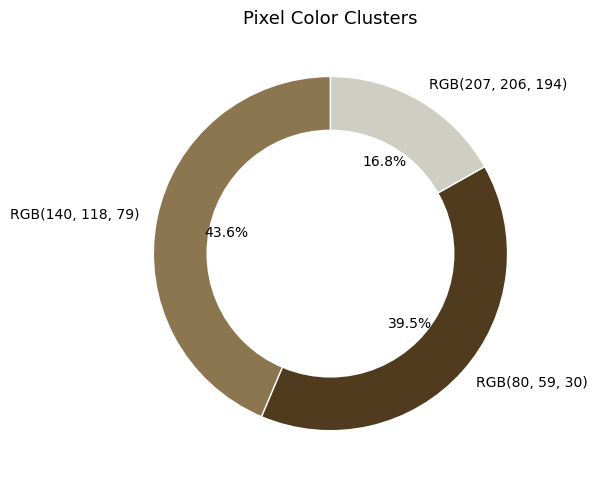

In [6]:
color_pcts = [percent for _, percent in results]
color_values = [tuple(c / 255 for c in color) for color, _ in results]
color_labels = [f'RGB{tuple(int(c) for c in color)}' for color, _ in results]

fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    color_pcts,
    labels=color_labels,
    colors=color_values,
    autopct='%.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.4, edgecolor='w'),
    textprops=dict(color='black')
)

centre_circle = plt.Circle((0, 0), 0.70, fc='white')
ax.add_artist(centre_circle)

ax.set_title('Pixel Color Clusters', fontsize=13)
plt.tight_layout()
plt.show()

## Visualization of clusters
Visualization of clustering of k-means results

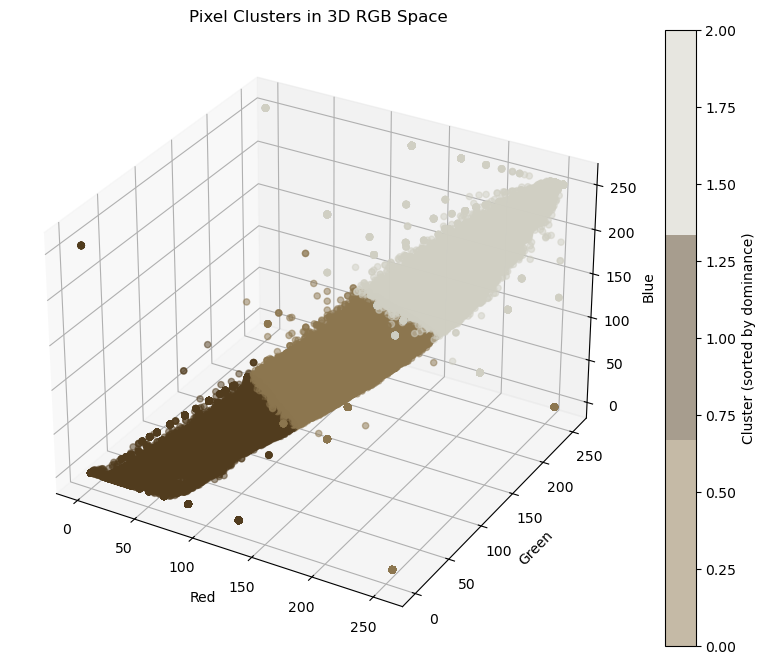

In [3]:
from matplotlib.colors import ListedColormap

# Compute cluster centers and counts
centers = []
counts = []
num_clusters = len(results)
for i in range(num_clusters):
    mask = labels == i
    center = pixels[mask].mean(axis=0)
    centers.append(center)
    counts.append(np.sum(mask))

centers = np.array(centers)
counts = np.array(counts)

# Sort by counts descending
sorted_idx = np.argsort(counts)[::-1]

# Sorted centers
sorted_centers = centers[sorted_idx]

# Remap labels to sorted order
new_labels = np.zeros_like(labels)
for new_i, old_i in enumerate(sorted_idx):
    new_labels[labels == old_i] = new_i

# Create colormap from sorted centers
cmap = ListedColormap(sorted_centers / 255.0)

# Plot the pixels in 3D RGB space colored by cluster
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pixels[:, 0], pixels[:, 1], pixels[:, 2], c=new_labels, cmap=cmap, alpha=0.5)
ax.set_title('Pixel Clusters in 3D RGB Space')
ax.set_xlabel('Red')
ax.set_ylabel('Green')
ax.set_zlabel('Blue', rotation=90)
plt.colorbar(ax.collections[0], label='Cluster (sorted by dominance)')
plt.show()
